## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [105]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [106]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [107]:
rng = np.random.default_rng(seed=42)

In [108]:
from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [109]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (20682, 1321)
counts (after):  (20682, 1321)


### For filtering specific variants

In [110]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.06,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


In [111]:
counts[['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculate Aggregate level values

1. Get the columns that are area, roundness and ratio and non-SER features
2. Drop those columns
3. Sort the remaining columns to get their labels

In [112]:
cell_line_agg_df = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna()
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [113]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2415.820238,1068.276350,2115.358462,9310.675777,1123.228563,2.418000e+06,47.227396,3635.190569,0.133404,97.131325,...,0.066482,0.051583,0.044348,0.074617,0.730109,0.257773,0.476910,0.270425,0.000529,0.004023
LRRK2,2021.875701,1112.009004,1704.602551,9416.777551,785.303571,1.903551e+06,52.428042,3175.903571,0.221412,82.328004,...,0.060666,0.043065,0.040697,0.065448,0.723399,0.241826,0.531648,0.285185,0.000421,0.003122
PRKN,2076.053908,1952.357934,1410.677438,17065.391393,625.548616,2.735305e+06,94.056915,4003.532532,-0.133413,120.537051,...,0.083197,0.051577,0.039248,0.092716,0.748071,0.339158,0.710430,0.309782,0.000661,0.004936
SNCA,1951.625292,1429.647893,1496.251453,12805.726463,768.235761,2.151740e+06,73.047671,3316.071678,0.014999,102.527258,...,0.068528,0.047660,0.036714,0.074893,0.738253,0.372691,0.711612,0.341564,0.000580,0.004187


#### Create additional labels for region, star types and feature types 

In [114]:
all_columns = sorted_columns
regions = []
feature_types = []
star_types = []
organelles = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if ('Symmetry' in col_sections) or ('Threshold' in col_sections) or ('Axial' in col_sections) or ('Radial' in col_sections):
        star_types.append(star_type)
    elif  ('SER' in col_sections):
        star_types.append('SER')
        print(col_sections)
    else:
        star_types.append('None')
        # print(star_type)
   
    feature_types.append(feature)
    organelles.append(organelle)


['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '

### Generate Heatmap without clustering

In [115]:
heatmap_data = heatmap_data[sorted_columns]

In [116]:
heatmap_data

,General Dimension - Cell region Area µm²,General Dimension - Cell region Length µm,General Dimension - Cell region Perimeter µm,General Dimension - Cell region Ratio Width to Length,General Dimension - Cell region Roundness,General Dimension - Cell region Width µm,General Dimension - Inner region Area µm²,General Dimension - Inner region Length µm,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Ratio Width to Length,...,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Edge
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,726.568423,60.116848,248.655207,0.322360,0.467413,15.234849,69.908371,23.123662,81.646936,0.149160,...,0.372880,0.482062,0.440218,0.536161,0.666780,0.853476,0.182623,0.215760,0.271215,0.363345
LRRK2,551.602722,59.710121,207.900039,0.328606,0.505215,13.650582,55.854834,21.086466,75.302601,0.144719,...,0.473246,0.585673,0.547600,0.665468,0.813446,1.014845,0.208063,0.235347,0.280761,0.353870
PRKN,497.592223,44.346248,160.693610,0.395902,0.579722,14.199009,60.991108,24.662721,93.538966,0.126755,...,0.486229,0.615666,0.571232,0.694023,0.860937,1.087418,0.234399,0.273833,0.337551,0.438455
SNCA,574.458821,50.105260,196.204708,0.364344,0.517447,14.488753,62.952411,23.197042,86.567868,0.141231,...,0.493932,0.620715,0.573611,0.691312,0.842428,1.048112,0.238760,0.280370,0.343157,0.440367


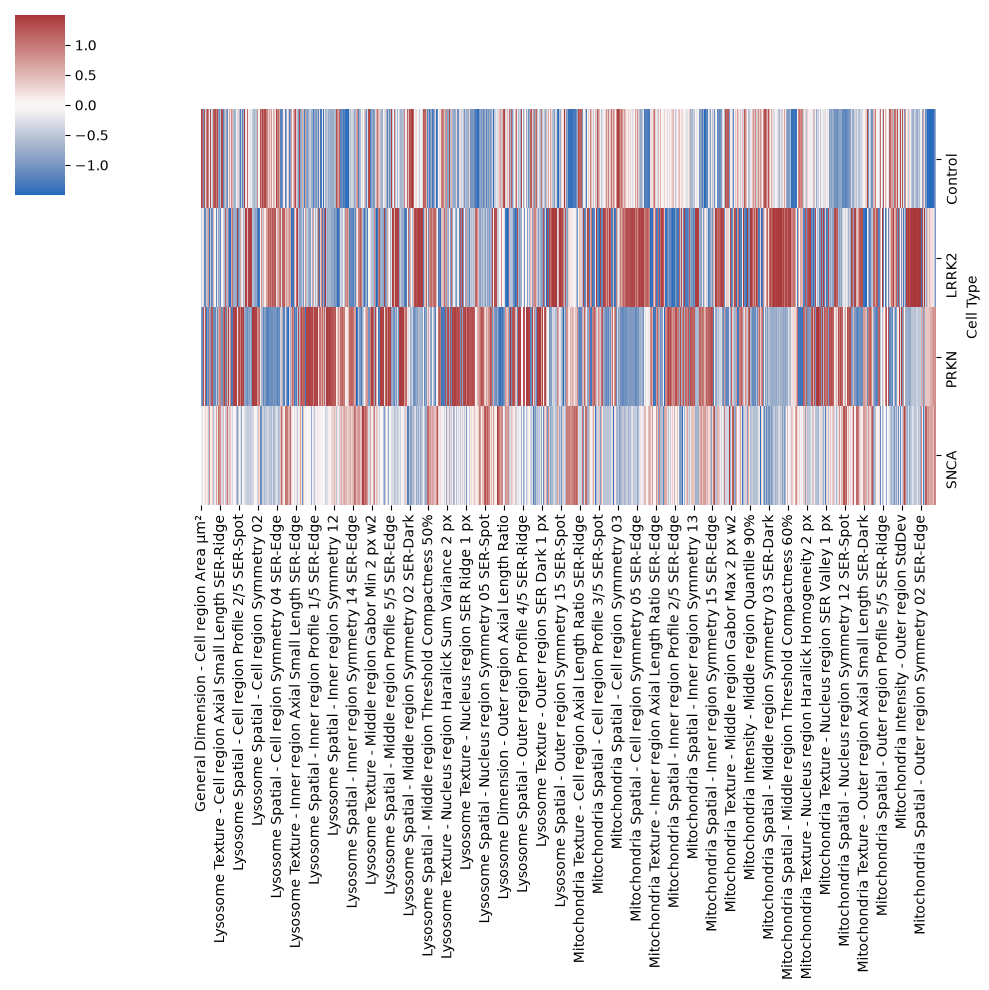

In [117]:
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
)

## Begin adding additional labels

In [118]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [119]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [120]:
set(star_types)

{'Axial', 'None', 'Radial', 'SER', 'Symmetry', 'Threshold'}

In [121]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

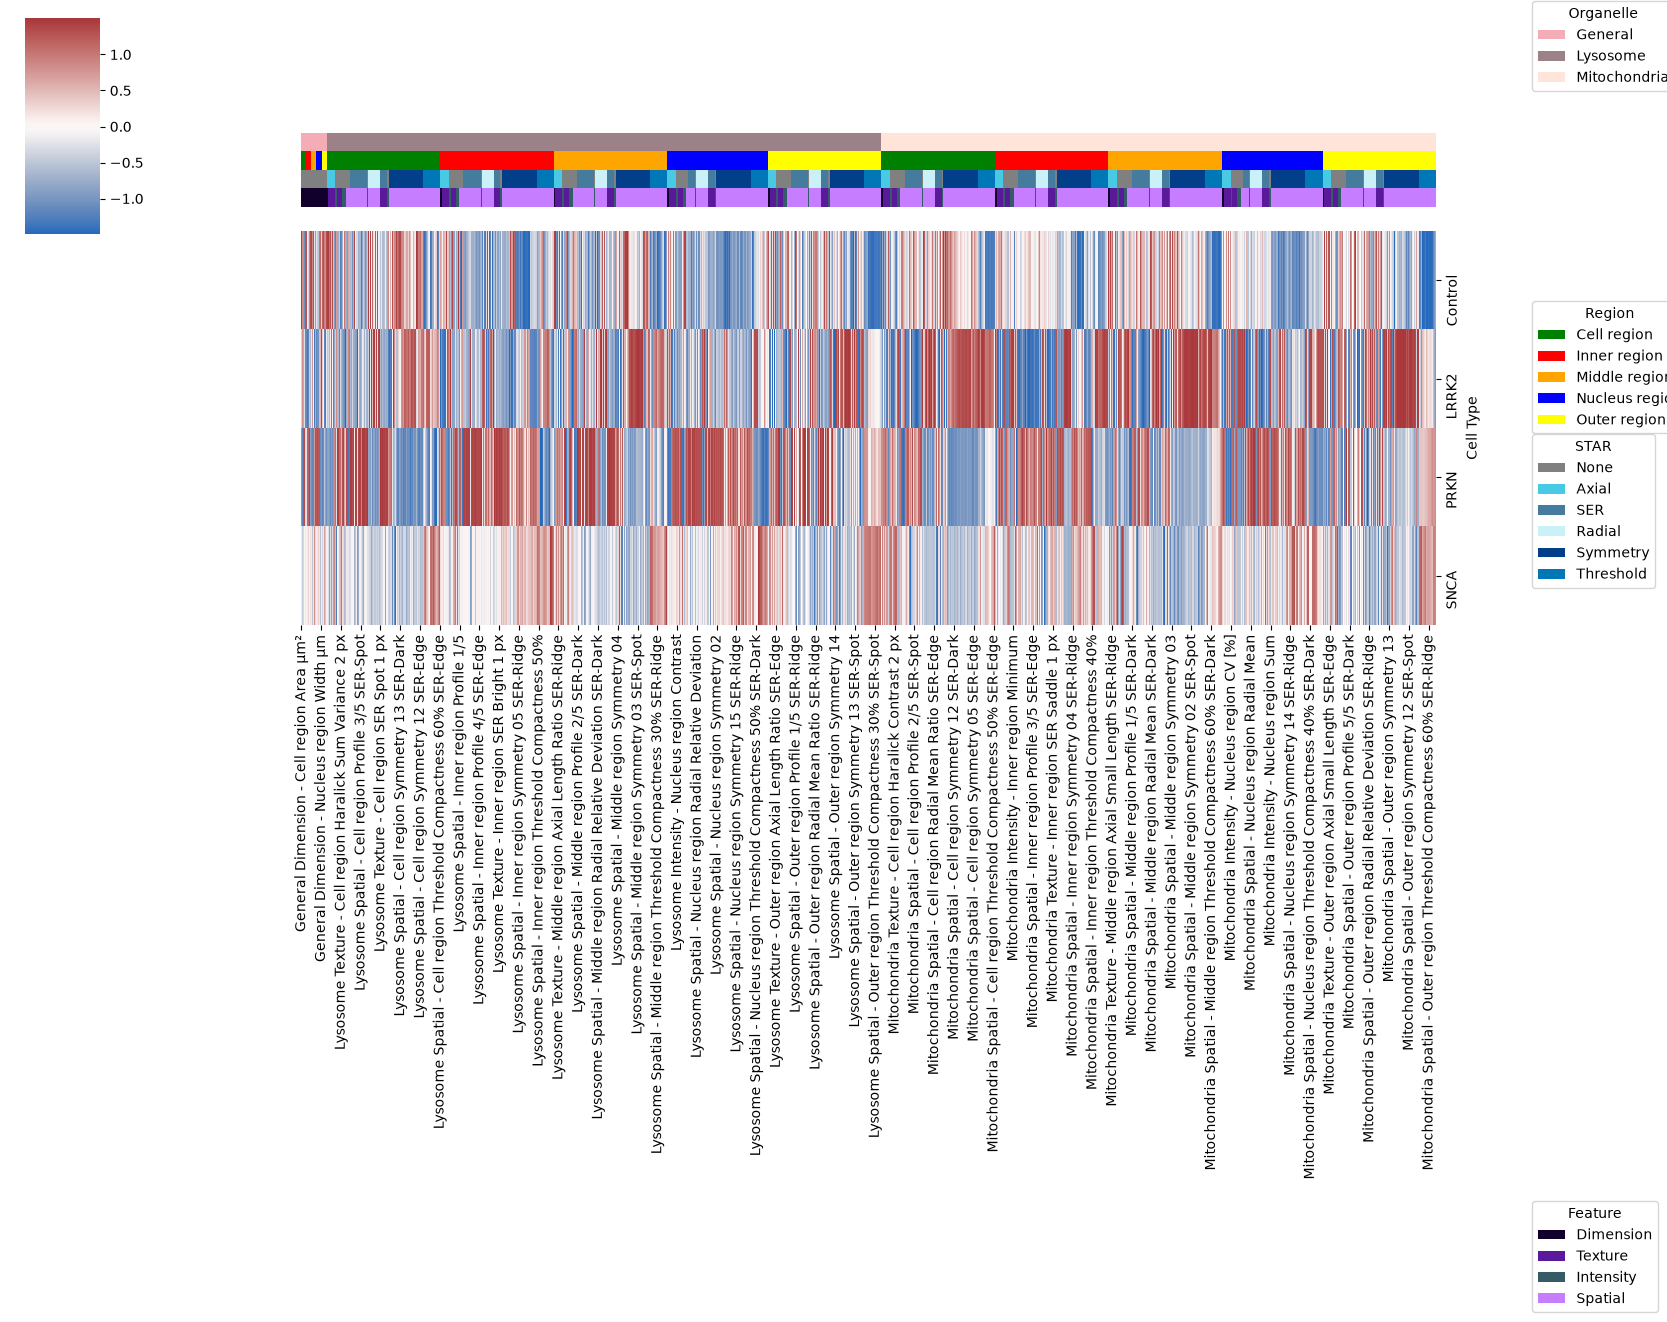

In [122]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = '#f4acb7'
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = '#9d8189'

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#023e8a'
    elif star == 'Threshold':
        star_color = '#0077b6'
    elif star == 'Axial':
        star_color = '#48cae4'
    elif star == 'Radial':
        star_color = '#caf0f8'
    else:
        star_color = '#457b9d'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#10002b'
    elif feature == 'Spatial':
        feature_color = '#c77dff'
    else:
        feature_color = '#5a189a'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]

g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)
# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')






In [123]:
heatmap_data[heatmap_data.columns[heatmap_data.std() == 0]]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
Cell Type,,,,,,,,,,
Control,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LRRK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PRKN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNCA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [124]:
heatmap_data = heatmap_data.astype('float')
print(np.isinf(heatmap_data).sum().sum())
print(heatmap_data.isna().sum().sum())
# print(heatmap_data)
zero_variance_cols = heatmap_data.columns[heatmap_data.std() == 0].tolist()
new_heatmap_data = heatmap_data
new_heatmap_data = new_heatmap_data.drop(columns=zero_variance_cols)

0
0


In [125]:
heatmap_data[zero_variance_cols]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
Cell Type,,,,,,,,,,
Control,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LRRK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PRKN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNCA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [126]:
print(zero_variance_cols)

['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']


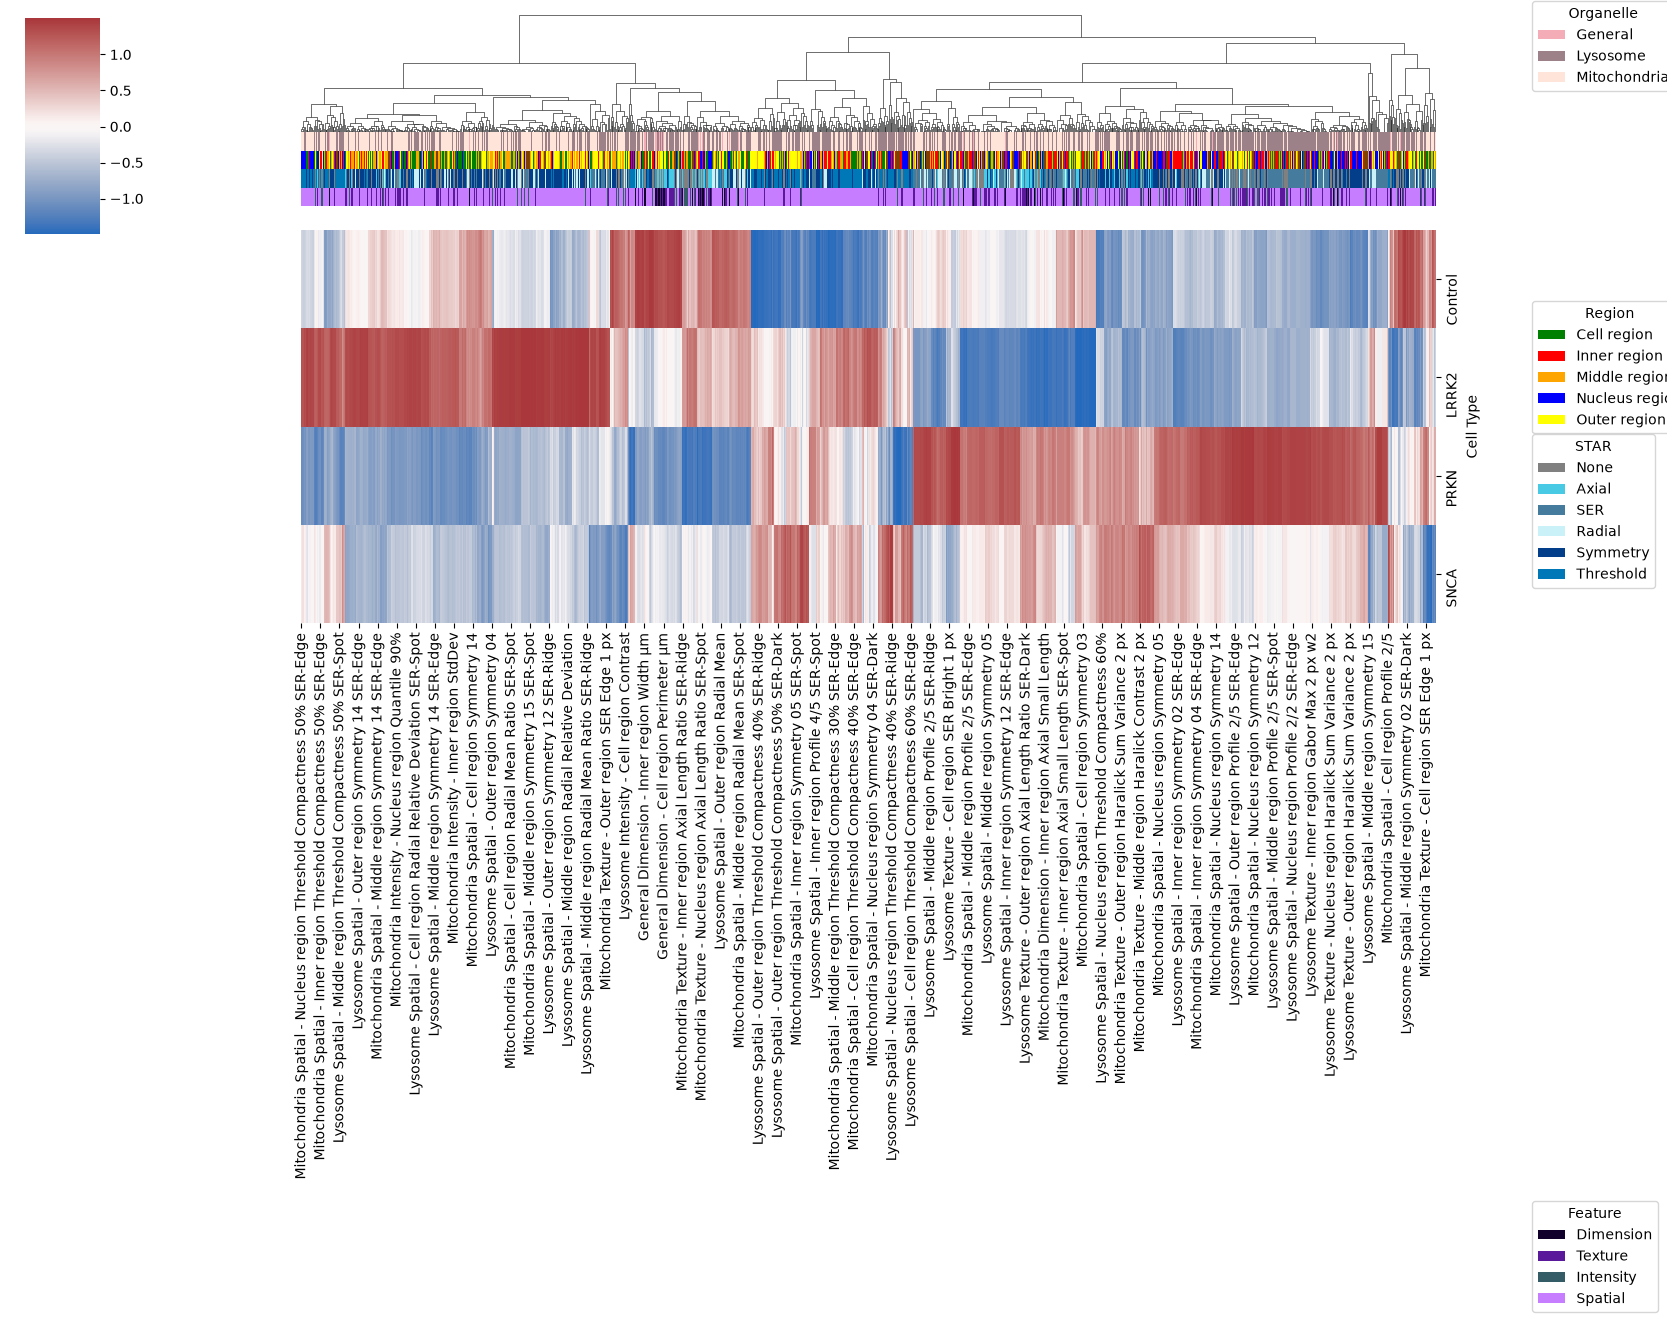

In [127]:
g = sns.clustermap(
    new_heatmap_data,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=True,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)
# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')




# ANOVA test

## Calculate the total variance for each column

In [128]:
counts = counts.fillna(0)
counts

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.490,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.910,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.960,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.060,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.610,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20677,Control,3616.290,1088.550,3333,8790,1595,2903880,30.1014,5165,0.438814,...,0.102622,0.054741,0.057066,0.116553,0.793894,0.335354,0.729709,0.304315,0.000631,0.005388
20678,Control,4788.780,1366.870,4346,10015,2758,4453560,28.5432,6550,0.351502,...,0.074396,0.048882,0.053659,0.087474,0.757420,0.187018,0.338722,0.224336,0.000522,0.004393
20679,Control,2129.650,478.452,2249,3096,835,792229,22.4662,2660,0.534789,...,0.062776,0.057318,0.062220,0.071961,0.621944,0.202679,0.217385,0.182647,0.000491,0.004536
20680,Control,973.986,266.398,939,1688,398,347713,27.3513,1368,0.272878,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [129]:
no_cell_type = counts.drop(columns=['Cell Type'])
whole_variance = no_cell_type.agg(['var'])
whole_variance

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
var,1.167516e+06,1.601232e+06,933669.744607,1.016894e+08,291444.101716,3.366374e+12,2034.555809,5.292019e+06,0.113424,4961.139529,...,0.001108,0.000285,0.000271,0.00125,0.017072,0.060619,0.339839,0.012298,3.745690e-08,0.000002


## Calculate the total variance per group

In [130]:
cell_type_var = counts.groupby(['Cell Type']).agg(['var'])
cell_type_var

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
,var,var,var,var,var,var,var,var,var,var,...,var,var,var,var,var,var,var,var,var,var
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,1.088614e+06,5.702468e+05,973099.366980,3.305468e+07,360326.989806,2.425750e+12,771.274207,3.282556e+06,0.070567,4651.139381,...,0.000639,0.000247,0.000267,0.000733,0.013680,0.022524,0.117608,0.007840,1.861566e-08,0.000001
LRRK2,1.066684e+06,1.062865e+06,806740.333531,6.656855e+07,188931.192637,2.136868e+12,1285.565128,4.041501e+06,0.108650,2525.543316,...,0.001344,0.000380,0.000419,0.001301,0.036934,0.022953,0.175710,0.012694,1.839085e-08,0.000001
PRKN,1.258655e+06,2.204646e+06,831909.846373,1.434450e+08,209171.497817,4.987770e+12,2411.622249,6.929120e+06,0.117931,5908.094074,...,0.001239,0.000234,0.000188,0.001433,0.016208,0.043327,0.277946,0.009977,4.529923e-08,0.000003
SNCA,1.042334e+06,1.760794e+06,692217.405079,1.034152e+08,180420.575485,2.575064e+12,1876.284279,5.809982e+06,0.101107,4418.462450,...,0.001182,0.000337,0.000294,0.001294,0.014776,0.136880,0.723072,0.017973,3.684001e-08,0.000002


In [131]:
# Calculate the ratio of min to max variance per column
def min_max_ratio(df):
    if df.min() == 0:
        return False
    
    return df.max()/df.min() < 4

min_max_var = pd.DataFrame(cell_type_var.agg(min_max_ratio), columns=['ANOVA safe'])
min_max_var

,,ANOVA safe
Lysosome Intensity - Nucleus region Mean,var,True
Lysosome Intensity - Nucleus region StdDev,var,True
Lysosome Intensity - Nucleus region Median,var,True
Lysosome Intensity - Nucleus region Maximum,var,False
Lysosome Intensity - Nucleus region Minimum,var,True
...,...,...
Mitochondria Texture - Outer region Haralick Contrast 2 px,var,False
Mitochondria Texture - Outer region Haralick Sum Variance 2 px,var,False
Mitochondria Texture - Outer region Haralick Homogeneity 2 px,var,True
Mitochondria Texture - Outer region Gabor Min 2 px w2,var,True


In [132]:
anova_safe_columns = min_max_var['ANOVA safe'].tolist()
cell_types = counts['Cell Type']
no_cell_types = counts.drop(columns=['Cell Type'])

anova_safe_data = no_cell_types.loc[:, anova_safe_columns]

In [133]:
anova_safe_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,General Dimension - Nucleus region Roundness,...,Mitochondria Texture - Outer region SER Edge 1 px,Mitochondria Texture - Outer region SER Ridge 1 px,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,1964.490,473.458,2001,747,1092250,24.1009,2558,0.547062,49.3480,0.810086,...,0.213693,0.047567,0.062429,0.055786,0.060275,0.080337,0.692103,0.195137,0.000550,0.004230
1,2582.910,555.290,2683,1303,883355,21.4986,3261,0.674363,30.3544,0.873518,...,0.207901,0.049970,0.056252,0.055994,0.062334,0.067784,0.661050,0.210063,0.000543,0.004167
2,3105.960,806.695,2904,1006,2963080,25.9725,4097,0.466701,84.6727,0.974200,...,0.226985,0.050783,0.047268,0.060245,0.063949,0.054644,0.708571,0.203688,0.000483,0.003577
3,1677.060,552.588,1557,779,753001,32.9498,2438,0.286715,39.8512,0.909084,...,0.282287,0.067030,0.084388,0.079462,0.080827,0.100119,0.681948,0.179421,0.000649,0.005440
4,3321.610,796.328,3175,1523,4354630,23.9741,4097,0.425068,116.3580,0.938167,...,0.203779,0.042372,0.057507,0.053676,0.054210,0.068928,0.770866,0.227847,0.000484,0.003702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20677,3616.290,1088.550,3333,1595,2903880,30.1014,5165,0.438814,71.2706,0.975492,...,0.271685,0.048013,0.102622,0.054741,0.057066,0.116553,0.793894,0.304315,0.000631,0.005388
20678,4788.780,1366.870,4346,2758,4453560,28.5432,6550,0.351502,82.5426,0.960034,...,0.238797,0.043468,0.074396,0.048882,0.053659,0.087474,0.757420,0.224336,0.000522,0.004393
20679,2129.650,478.452,2249,835,792229,22.4662,2660,0.534789,33.0170,0.986323,...,0.261724,0.049754,0.062776,0.057318,0.062220,0.071961,0.621944,0.182647,0.000491,0.004536
20680,973.986,266.398,939,398,347713,27.3513,1368,0.272878,31.6857,0.802765,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Use the stats module to calculate the anova test for each column

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
np.random.seed(12)

anova_safe_columns = anova_safe_data.columns
print(anova_safe_columns)

anova_safe_data['Cell Type'] = cell_types
anova_safe_data

Index(['Lysosome Intensity - Nucleus region Mean',
       'Lysosome Intensity - Nucleus region StdDev',
       'Lysosome Intensity - Nucleus region Median',
       'Lysosome Intensity - Nucleus region Minimum',
       'Lysosome Intensity - Nucleus region Sum',
       'Lysosome Intensity - Nucleus region CV [%]',
       'Lysosome Intensity - Nucleus region Quantile 90%',
       'Lysosome Intensity - Nucleus region Contrast',
       'General Dimension - Nucleus region Area µm²',
       'General Dimension - Nucleus region Roundness',
       ...
       'Mitochondria Texture - Outer region SER Ridge 1 px',
       'Mitochondria Texture - Outer region SER Valley 1 px',
       'Mitochondria Texture - Outer region SER Saddle 1 px',
       'Mitochondria Texture - Outer region SER Bright 1 px',
       'Mitochondria Texture - Outer region SER Dark 1 px',
       'Mitochondria Texture - Outer region Haralick Correlation 2 px',
       'Mitochondria Texture - Outer region Haralick Homogeneity 2 px',
 

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,General Dimension - Nucleus region Roundness,...,Mitochondria Texture - Outer region SER Ridge 1 px,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2,Cell Type
0,1964.490,473.458,2001,747,1092250,24.1009,2558,0.547062,49.3480,0.810086,...,0.047567,0.062429,0.055786,0.060275,0.080337,0.692103,0.195137,0.000550,0.004230,Control
1,2582.910,555.290,2683,1303,883355,21.4986,3261,0.674363,30.3544,0.873518,...,0.049970,0.056252,0.055994,0.062334,0.067784,0.661050,0.210063,0.000543,0.004167,Control
2,3105.960,806.695,2904,1006,2963080,25.9725,4097,0.466701,84.6727,0.974200,...,0.050783,0.047268,0.060245,0.063949,0.054644,0.708571,0.203688,0.000483,0.003577,Control
3,1677.060,552.588,1557,779,753001,32.9498,2438,0.286715,39.8512,0.909084,...,0.067030,0.084388,0.079462,0.080827,0.100119,0.681948,0.179421,0.000649,0.005440,Control
4,3321.610,796.328,3175,1523,4354630,23.9741,4097,0.425068,116.3580,0.938167,...,0.042372,0.057507,0.053676,0.054210,0.068928,0.770866,0.227847,0.000484,0.003702,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20677,3616.290,1088.550,3333,1595,2903880,30.1014,5165,0.438814,71.2706,0.975492,...,0.048013,0.102622,0.054741,0.057066,0.116553,0.793894,0.304315,0.000631,0.005388,Control
20678,4788.780,1366.870,4346,2758,4453560,28.5432,6550,0.351502,82.5426,0.960034,...,0.043468,0.074396,0.048882,0.053659,0.087474,0.757420,0.224336,0.000522,0.004393,Control
20679,2129.650,478.452,2249,835,792229,22.4662,2660,0.534789,33.0170,0.986323,...,0.049754,0.062776,0.057318,0.062220,0.071961,0.621944,0.182647,0.000491,0.004536,Control
20680,973.986,266.398,939,398,347713,27.3513,1368,0.272878,31.6857,0.802765,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Control


In [136]:
signifcant_columns = []

# Overall significantly affected columns

In [146]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2'][col]
    prrkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]

    # Perform ANOVA
    if col != 'Cell Type':
        val = stats.f_oneway(control, lrrk2, prrkn, snca)
    
    
        print(col, ':')
        print(val)
        print("")

        if val.pvalue < 0.05:
            signifcant_columns.append(col)

    else:
        print("DONE!")

Lysosome Intensity - Nucleus region Mean :
F_onewayResult(statistic=np.float64(219.00579882936492), pvalue=np.float64(7.157687635430836e-140))

Lysosome Intensity - Nucleus region StdDev :
F_onewayResult(statistic=np.float64(670.7375856931536), pvalue=np.float64(0.0))

Lysosome Intensity - Nucleus region Median :
F_onewayResult(statistic=np.float64(768.6247005553938), pvalue=np.float64(0.0))

Lysosome Intensity - Nucleus region Minimum :
F_onewayResult(statistic=np.float64(1184.262668291792), pvalue=np.float64(0.0))

Lysosome Intensity - Nucleus region Sum :
F_onewayResult(statistic=np.float64(159.81993452437567), pvalue=np.float64(2.0586380104436176e-102))

Lysosome Intensity - Nucleus region CV [%] :
F_onewayResult(statistic=np.float64(1643.050841880751), pvalue=np.float64(0.0))

Lysosome Intensity - Nucleus region Quantile 90% :
F_onewayResult(statistic=np.float64(120.17161260782758), pvalue=np.float64(3.695453951664821e-77))

Lysosome Intensity - Nucleus region Contrast :
F_onewayR

In [148]:
len(signifcant_columns)

1252

In [160]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [161]:
for col in signifcant_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

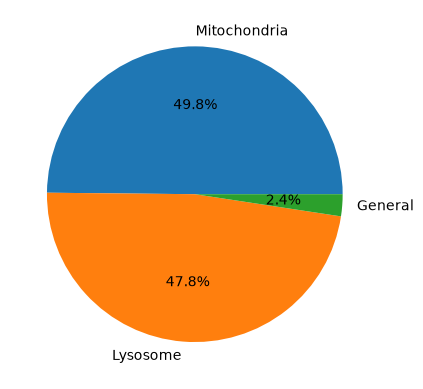

In [162]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# LRRK2 vs Control

In [149]:
lrrk2_sig_columns = []

In [150]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2'][col]
   

    # Perform ANOVA
    if col == 'Cell Type':
        print("DONE!")
        break

    val = stats.f_oneway(control, lrrk2)

    if val.pvalue < 0.05:
        lrrk2_sig_columns.append(col)
    
    print(col, ':')
    print(val)
    print("")

Lysosome Intensity - Nucleus region Mean :
F_onewayResult(statistic=np.float64(216.8692505138914), pvalue=np.float64(1.6886182349328217e-48))

Lysosome Intensity - Nucleus region StdDev :
F_onewayResult(statistic=np.float64(4.24505413092367), pvalue=np.float64(0.039394768138773587))

Lysosome Intensity - Nucleus region Median :
F_onewayResult(statistic=np.float64(273.17102099752054), pvalue=np.float64(1.9561643035551115e-60))

Lysosome Intensity - Nucleus region Minimum :
F_onewayResult(statistic=np.float64(538.089831518161), pvalue=np.float64(1.6114662754199947e-115))

Lysosome Intensity - Nucleus region Sum :
F_onewayResult(statistic=np.float64(169.81180274915323), pvalue=np.float64(1.8755330425558757e-38))

Lysosome Intensity - Nucleus region CV [%] :
F_onewayResult(statistic=np.float64(46.1121172990085), pvalue=np.float64(1.1907015531153078e-11))

Lysosome Intensity - Nucleus region Quantile 90% :
F_onewayResult(statistic=np.float64(92.45203089245041), pvalue=np.float64(8.870326552

In [155]:
print(lrrk2_sig_columns)
print(len(lrrk2_sig_columns))

['Lysosome Intensity - Nucleus region Mean', 'Lysosome Intensity - Nucleus region StdDev', 'Lysosome Intensity - Nucleus region Median', 'Lysosome Intensity - Nucleus region Minimum', 'Lysosome Intensity - Nucleus region Sum', 'Lysosome Intensity - Nucleus region CV [%]', 'Lysosome Intensity - Nucleus region Quantile 90%', 'Lysosome Intensity - Nucleus region Contrast', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Roundness', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'General Dimension - Nucleus region Ratio Width to Length', 'Lysosome Spatial - Nucleus region Symmetry 02', 'Lysosome Spatial - Nucleus region Symmetry 03', 'Lysosome Spatial - Nucleus region Symmetry 04', 'Lysosome Spatial - Nucleus region Symmetry 05', 'Lysosome Spatial - Nucleus region Symmetry 12', 'Lysosome Spatial - Nucleus region Symmetry 13', 'Lysosome Spatial - Nucleus regi

In [163]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [164]:
for col in lrrk2_sig_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

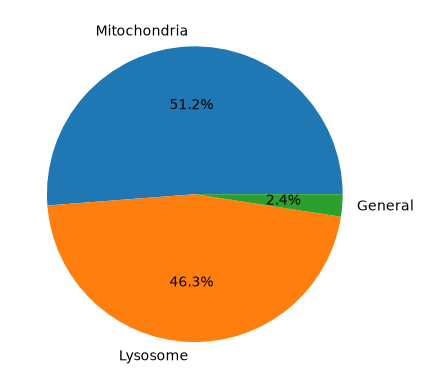

In [165]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# PRKN vs Control

In [151]:
prkn_sig_cols = []

In [152]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    print(control)
    prkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN'][col]
    # Perform ANOVA
    if col == 'Cell Type':
        print("DONE!")
        break

    # Perform ANOVA
    val = stats.f_oneway(control, prkn)

    if val.pvalue < 0.05:
            prkn_sig_cols.append(col)
    
    print(col, ':')
    print(val)
    print("")

0        1964.490
1        2582.910
2        3105.960
3        1677.060
4        3321.610
           ...   
20677    3616.290
20678    4788.780
20679    2129.650
20680     973.986
20681    2770.120
Name: Lysosome Intensity - Nucleus region Mean, Length: 6659, dtype: float64
Lysosome Intensity - Nucleus region Mean :
F_onewayResult(statistic=np.float64(332.91080879593295), pvalue=np.float64(1.687889603419524e-73))

0         473.458
1         555.290
2         806.695
3         552.588
4         796.328
           ...   
20677    1088.550
20678    1366.870
20679     478.452
20680     266.398
20681     447.871
Name: Lysosome Intensity - Nucleus region StdDev, Length: 6659, dtype: float64
Lysosome Intensity - Nucleus region StdDev :
F_onewayResult(statistic=np.float64(1889.243546089238), pvalue=np.float64(0.0))

0        2001
1        2683
2        2904
3        1557
4        3175
         ... 
20677    3333
20678    4346
20679    2249
20680     939
20681    2784
Name: Lysosome Intensity 

In [153]:
len(prkn_sig_cols)

1161

In [166]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [167]:
for col in prkn_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

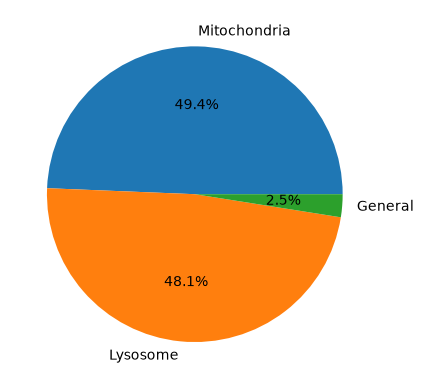

In [168]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# SNCA vs Control

In [156]:
snca_sig_cols = []

In [158]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]
    # Perform ANOVA
    if col == 'Cell Type':
        print("DONE!")
        break

    # Perform ANOVA
    val = stats.f_oneway(control, snca)
    if val.pvalue < 0.05:
            snca_sig_cols.append(col)
    
    print(col, ':')
    print(val)
    print("")

Lysosome Intensity - Nucleus region Mean :
F_onewayResult(statistic=np.float64(586.4590480375974), pvalue=np.float64(1.7312344058481862e-126))

Lysosome Intensity - Nucleus region StdDev :
F_onewayResult(statistic=np.float64(348.34156700963166), pvalue=np.float64(1.2241900189235001e-76))

Lysosome Intensity - Nucleus region Median :
F_onewayResult(statistic=np.float64(1310.560687991831), pvalue=np.float64(3.0340233926826057e-272))

Lysosome Intensity - Nucleus region Minimum :
F_onewayResult(statistic=np.float64(1300.5327842357349), pvalue=np.float64(2.7825505592929332e-270))

Lysosome Intensity - Nucleus region Sum :
F_onewayResult(statistic=np.float64(82.76013101686281), pvalue=np.float64(1.0738207868121198e-19))

Lysosome Intensity - Nucleus region CV [%] :
F_onewayResult(statistic=np.float64(1546.2037924727483), pvalue=np.float64(0.0))

Lysosome Intensity - Nucleus region Quantile 90% :
F_onewayResult(statistic=np.float64(67.51320876181255), pvalue=np.float64(2.310308633994261e-16)

In [159]:
print(snca_sig_cols)
print(len(snca_sig_cols))

['Lysosome Intensity - Nucleus region Mean', 'Lysosome Intensity - Nucleus region StdDev', 'Lysosome Intensity - Nucleus region Median', 'Lysosome Intensity - Nucleus region Minimum', 'Lysosome Intensity - Nucleus region Sum', 'Lysosome Intensity - Nucleus region CV [%]', 'Lysosome Intensity - Nucleus region Quantile 90%', 'Lysosome Intensity - Nucleus region Contrast', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Roundness', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'General Dimension - Nucleus region Ratio Width to Length', 'Lysosome Spatial - Nucleus region Symmetry 02', 'Lysosome Spatial - Nucleus region Symmetry 03', 'Lysosome Spatial - Nucleus region Symmetry 04', 'Lysosome Spatial - Nucleus region Symmetry 05', 'Lysosome Spatial - Nucleus region Symmetry 12', 'Lysosome Spatial - Nucleus region Symmetry 13', 'Lysosome Spatial - Nucleus regi

In [172]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [173]:
for col in snca_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

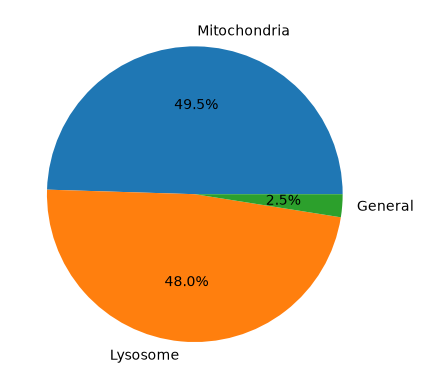

In [174]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')